In [2]:
import torch
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set()

# CSVを読み込む
df = pd.read_csv('../data/0_KL/1_ShadowHand_SAPG_s4_KL.csv')
#df = pd.read_csv('../data/0_KL/1_ShadowHand_CPOwoAdR_s4_KL.csv')
#df = pd.read_csv('../data/0_KL/1_ShadowHand_CPOwAdR_s4_KL.csv')

#df = pd.read_csv('../data/0_KL/2_AllegroHand_SAPG_s4_KL.csv')
#df = pd.read_csv('../data/0_KL/1_AllegroHand_CPOwoAdR_s4_KL.csv')


print(len(df)) # 全部で52000になる

/home/mil/shitanda/.pyenv/versions/anaconda3-2023.03/envs/sapg2/lib/python3.7/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


104000


target_envstep 15000000000
target_epoch 76293
tensor([[-6.2932e-03,  1.4399e+01,  2.2243e+00,  3.7006e-01,  2.2961e-01,
          6.1019e-01],
        [ 6.5935e+00, -8.7242e-03,  4.2308e+00,  5.5837e+00,  7.4035e+00,
          8.9364e+00],
        [ 1.4989e+00,  6.0233e+00, -8.2113e-03,  1.2093e+00,  1.8398e+00,
          3.1564e+00],
        [ 3.1535e-01,  1.0399e+01,  1.5314e+00, -7.3255e-03,  8.0952e-01,
          1.5119e+00],
        [ 2.3408e-01,  1.6351e+01,  2.7895e+00,  9.8938e-01, -6.3060e-03,
          6.2343e-01],
        [ 7.5650e-01,  2.4100e+01,  5.7476e+00,  2.1965e+00,  7.5096e-01,
         -5.7218e-03]])


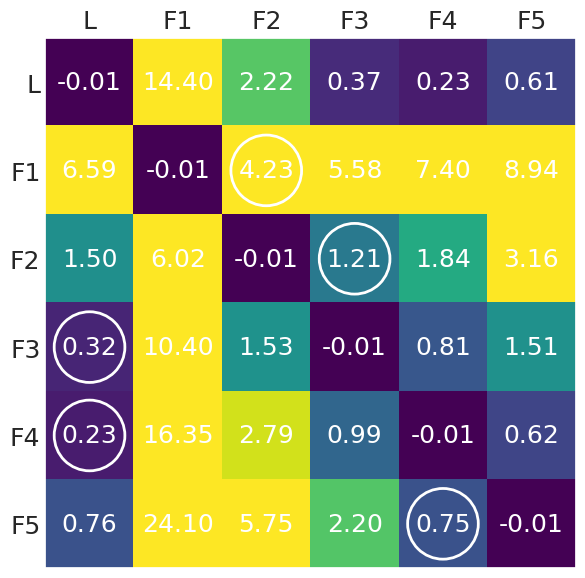

In [ ]:

target_envstep = 15 * 10**9
horizon_length = 8
num_envs = 24576

target_epoch = int(target_envstep / (horizon_length * num_envs))
print("target_envstep", target_envstep)
print("target_epoch", target_epoch)

#target_epoch = 50000



row = df.iloc[target_epoch]  # 1行目だけ取り出す (Series)
# numpy配列にしてからtensor化
tensor = torch.tensor(row.values, dtype=torch.float32).view(6, 6)
tensor = torch.flip(tensor.flatten(), dims=[0]).view(6, 6)


print(tensor)


# ラベルとダミー tensor（適宜置き換えてください）
labels = ["L", "F1", "F2", "F3", "F4", "F5"]


fig, ax = plt.subplots(figsize=(6, 6))

# imshow で値を表示
im = ax.imshow(tensor.numpy(), cmap='viridis', vmin=0, vmax=3)

# 主目盛（ラベル用）
ax.set_xticks(np.arange(6))
ax.set_yticks(np.arange(6))

ax.set_xticklabels(labels, fontsize=18)
ax.set_yticklabels(labels, fontsize=18)

ax.xaxis.set_ticks_position('top')      # 目盛り（数字）を上側に
ax.xaxis.set_label_position('top')      # 軸ラベル（Xの名前など）がある場合の位置

# グリッド線をセルの境界に描画するためのマイナー目盛


#ax.grid(which='minor', color='white', linestyle='-', linewidth=0)
ax.grid(False)

# 主目盛の線は消して、すっきりさせる
ax.tick_params(which='major', length=0)


# 各セルに数値を表示 & 各行の最小値の位置（L行と対角を除く）に丸を描く
for i in range(6):
    row_min_val = float('inf')
    row_min_pos = None
    for j in range(6):
        val = tensor[i, j]
        ax.text(j, i, f"{val:.2f}", ha='center', va='center', color='white', fontsize=18)

        # L行（i==0）と対角（i==j）を除外して最小を探す
        if i != 0 and i != j and val < row_min_val:
            row_min_val = val
            row_min_pos = (i, j)

    # 最小値が見つかったら丸を描画
    if row_min_pos:
        circle = plt.Circle((row_min_pos[1], row_min_pos[0]), 0.4, color='white', fill=False, linewidth=2)
        ax.add_patch(circle)

# タイトル（任意）
#ax.set_title("Epoch 0 / 0")

# カラーバーとレイアウト調整
#fig.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

# svgに出力
fig.savefig("kl.svg", format="svg", bbox_inches='tight', pad_inches=0.1)